# Portfolio Construction and Backtest

This notebook translates the residual z-score signal into portfolio weights and simulates historical performance.

**Three portfolio versions:**

| Version | Description |
|---------|-------------|
| V1 | Equal-weight dollar-neutral (baseline) |
| V2 | Signal-weighted dollar-neutral (stronger deviations get larger positions) |
| V3 | Factor-neutral equal-weight (V1 weights projected onto the orthogonal complement of rolling PCA loadings) |

**Backtest parameters:** daily rebalancing, gross exposure $G = 1$, threshold $c = 1.0$, main cost assumption 5 bps.

**Timing convention:** weights at date $t$ use information through $t-1$. The backtest pairs `weights[t]` with `log_returns.shift(-1)[t]`. Do not shift weights by one day.

In [17]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath("..")
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

from pca_residual_mean_reversion.backtest import backtest
from pca_residual_mean_reversion.metrics import perf_metrics
from pca_residual_mean_reversion.portfolio import (
    build_weights_equal,
    build_weights_signal,
    compute_factor_exposures,
    neutralize_single_day_weights_safe,
    neutralize_weights_over_time,
)

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

PROCESSED = "../data/processed"

PCA_OUTPUT_SUFFIX = "_L126_K10_M20"  # must match OUTPUT_SUFFIX in notebook 2.0

# Main backtest parameters
C_MAIN       = 1.0    # z-score threshold
G            = 1.0    # gross exposure
W_MAX        = 0.05   # max single-name weight
COST_BPS_MAIN = 5     # main cost assumption for results table
COSTS        = [0, 1, 5, 10]   # transaction costs for sensitivity grid

2026-05-04 01:45:32.927 | INFO     | pca_residual_mean_reversion.config:<module>:11 - PROJ_ROOT path is: /Users/ashleygarcia/Workspace/pca-residual-mean-reversion


## 1. Load Data

In [18]:
# Timing convention:
# zscores and weights are indexed by first tradable date.
# weights[t] are computed using data through t-1.
# The daily-rebalanced backtest pairs weights[t] with log_returns.shift(-1)[t].
log_returns = pd.read_parquet(f"{PROCESSED}/log_returns.parquet")
zscores     = pd.read_parquet(f"{PROCESSED}/residual_zscores{PCA_OUTPUT_SUFFIX}.parquet")

rolling_loadings_path = f"{PROCESSED}/pca_rolling_loadings{PCA_OUTPUT_SUFFIX}.pkl"
if not os.path.exists(rolling_loadings_path):
    raise FileNotFoundError(
        f"Missing {rolling_loadings_path}. Re-run notebook 2.0 to produce rolling loadings."
    )
with open(rolling_loadings_path, "rb") as f:
    rolling_loadings_payload = pickle.load(f)
rolling_loadings = rolling_loadings_payload["loadings_by_date"]

# Restrict to clean universe
shared_cols = zscores.columns.intersection(log_returns.columns)
log_returns = log_returns[shared_cols]
zscores     = zscores[shared_cols]

print(f"Log returns      : {log_returns.shape}")
print(f"Z-scores         : {zscores.shape}")
print(f"Rolling loadings : {len(rolling_loadings)} dates")

Log returns      : (3730, 200)
Z-scores         : (3584, 200)
Rolling loadings : 3604 dates


---
## 2. Portfolio Weight Construction

### V1 — Equal-Weight Dollar-Neutral

All stocks crossing the threshold receive equal weight. Long and short sides are each normalised to $G/2$:

$$w_{i,t} = \begin{cases} \frac{G}{2|L_t|} & i \in L_t \\ -\frac{G}{2|S_t|} & i \in S_t \\ 0 & \text{otherwise} \end{cases}$$

### V2 — Signal-Weighted Dollar-Neutral

Weights are proportional to signal strength $s_{i,t} = -z_{i,t}$, normalised separately on each side so gross exposure stays at $G$.

Stocks with extreme z-scores get larger positions than those just barely crossing the threshold.

In [19]:
# Shared weight builders now live in pca_residual_mean_reversion.portfolio.
# build_weights_equal and build_weights_signal were imported in Cell 1.

In [20]:
def neutralize_single_day_weights(
    w_row: pd.Series, B_t: pd.DataFrame, G: float = 1.0, w_max: float = None
) -> pd.Series:
    return neutralize_single_day_weights_safe(w_row, B_t, G=G, w_max=w_max)


# Shared neutralization and factor-exposure helpers now live in
# pca_residual_mean_reversion.portfolio and were imported in Cell 1.

In [21]:
weights_v1 = build_weights_equal(zscores,  c=C_MAIN, G=G, w_max=W_MAX)
weights_v2 = build_weights_signal(zscores, c=C_MAIN, G=G, w_max=W_MAX)
weights_v3 = neutralize_weights_over_time(weights_v1, rolling_loadings, G=G, w_max=W_MAX)

print("Weight sanity checks")
for name, w in [("V1", weights_v1), ("V2", weights_v2), ("V3", weights_v3)]:
    net   = w.sum(axis=1)
    gross = w.abs().sum(axis=1)
    print(f"  {name}  net exposure  — mean: {net.mean():.6f}  max|net|: {net.abs().max():.6f}")
    print(f"  {name}  gross exposure — mean: {gross.mean():.4f}  min: {gross[gross>0].min():.4f}")

Weight sanity checks
  V1  net exposure  — mean: -0.000283  max|net|: 0.500000
  V1  gross exposure — mean: 1.0000  min: 1.0000
  V2  net exposure  — mean: -0.000657  max|net|: 0.500000
  V2  gross exposure — mean: 1.0000  min: 1.0000
  V3  net exposure  — mean: 0.000036  max|net|: 0.231962
  V3  gross exposure — mean: 1.0000  min: 1.0000


---
## 3. Factor Exposure Diagnostic — V1 vs V3

Dollar neutrality does not guarantee factor neutrality. V1 and V2 can still tilt toward or against PCA factors. V3 removes this exposure by projecting V1 weights onto the orthogonal complement of the rolling PCA loading matrix at each date.

Factor exposure is $B_t^\top w_t$ where $B_t \in \mathbb{R}^{N \times k}$ are the loadings from the window ending on $t-1$.

In [22]:
exp_v1 = compute_factor_exposures(weights_v1, rolling_loadings)
exp_v3 = compute_factor_exposures(weights_v3, rolling_loadings)

k = exp_v1.shape[1]
print("Mean absolute factor exposure (B_t^T w_t)")
summary = pd.DataFrame({
    "V1 mean |exp|"                  : exp_v1.abs().mean(),
    "V3 factor-neutral mean |exp|"   : exp_v3.abs().mean(),
})
print(summary.to_string())

Mean absolute factor exposure (B_t^T w_t)
      V1 mean |exp|  V3 factor-neutral mean |exp|
PC1        0.002080                      0.001545
PC2        0.004574                      0.000192
PC3        0.004628                      0.000136
PC4        0.004648                      0.000105
PC5        0.004670                      0.000102
PC6        0.004692                      0.000075
PC7        0.004609                      0.000062
PC8        0.004669                      0.000067
PC9        0.004713                      0.000056
PC10       0.004972                      0.000053


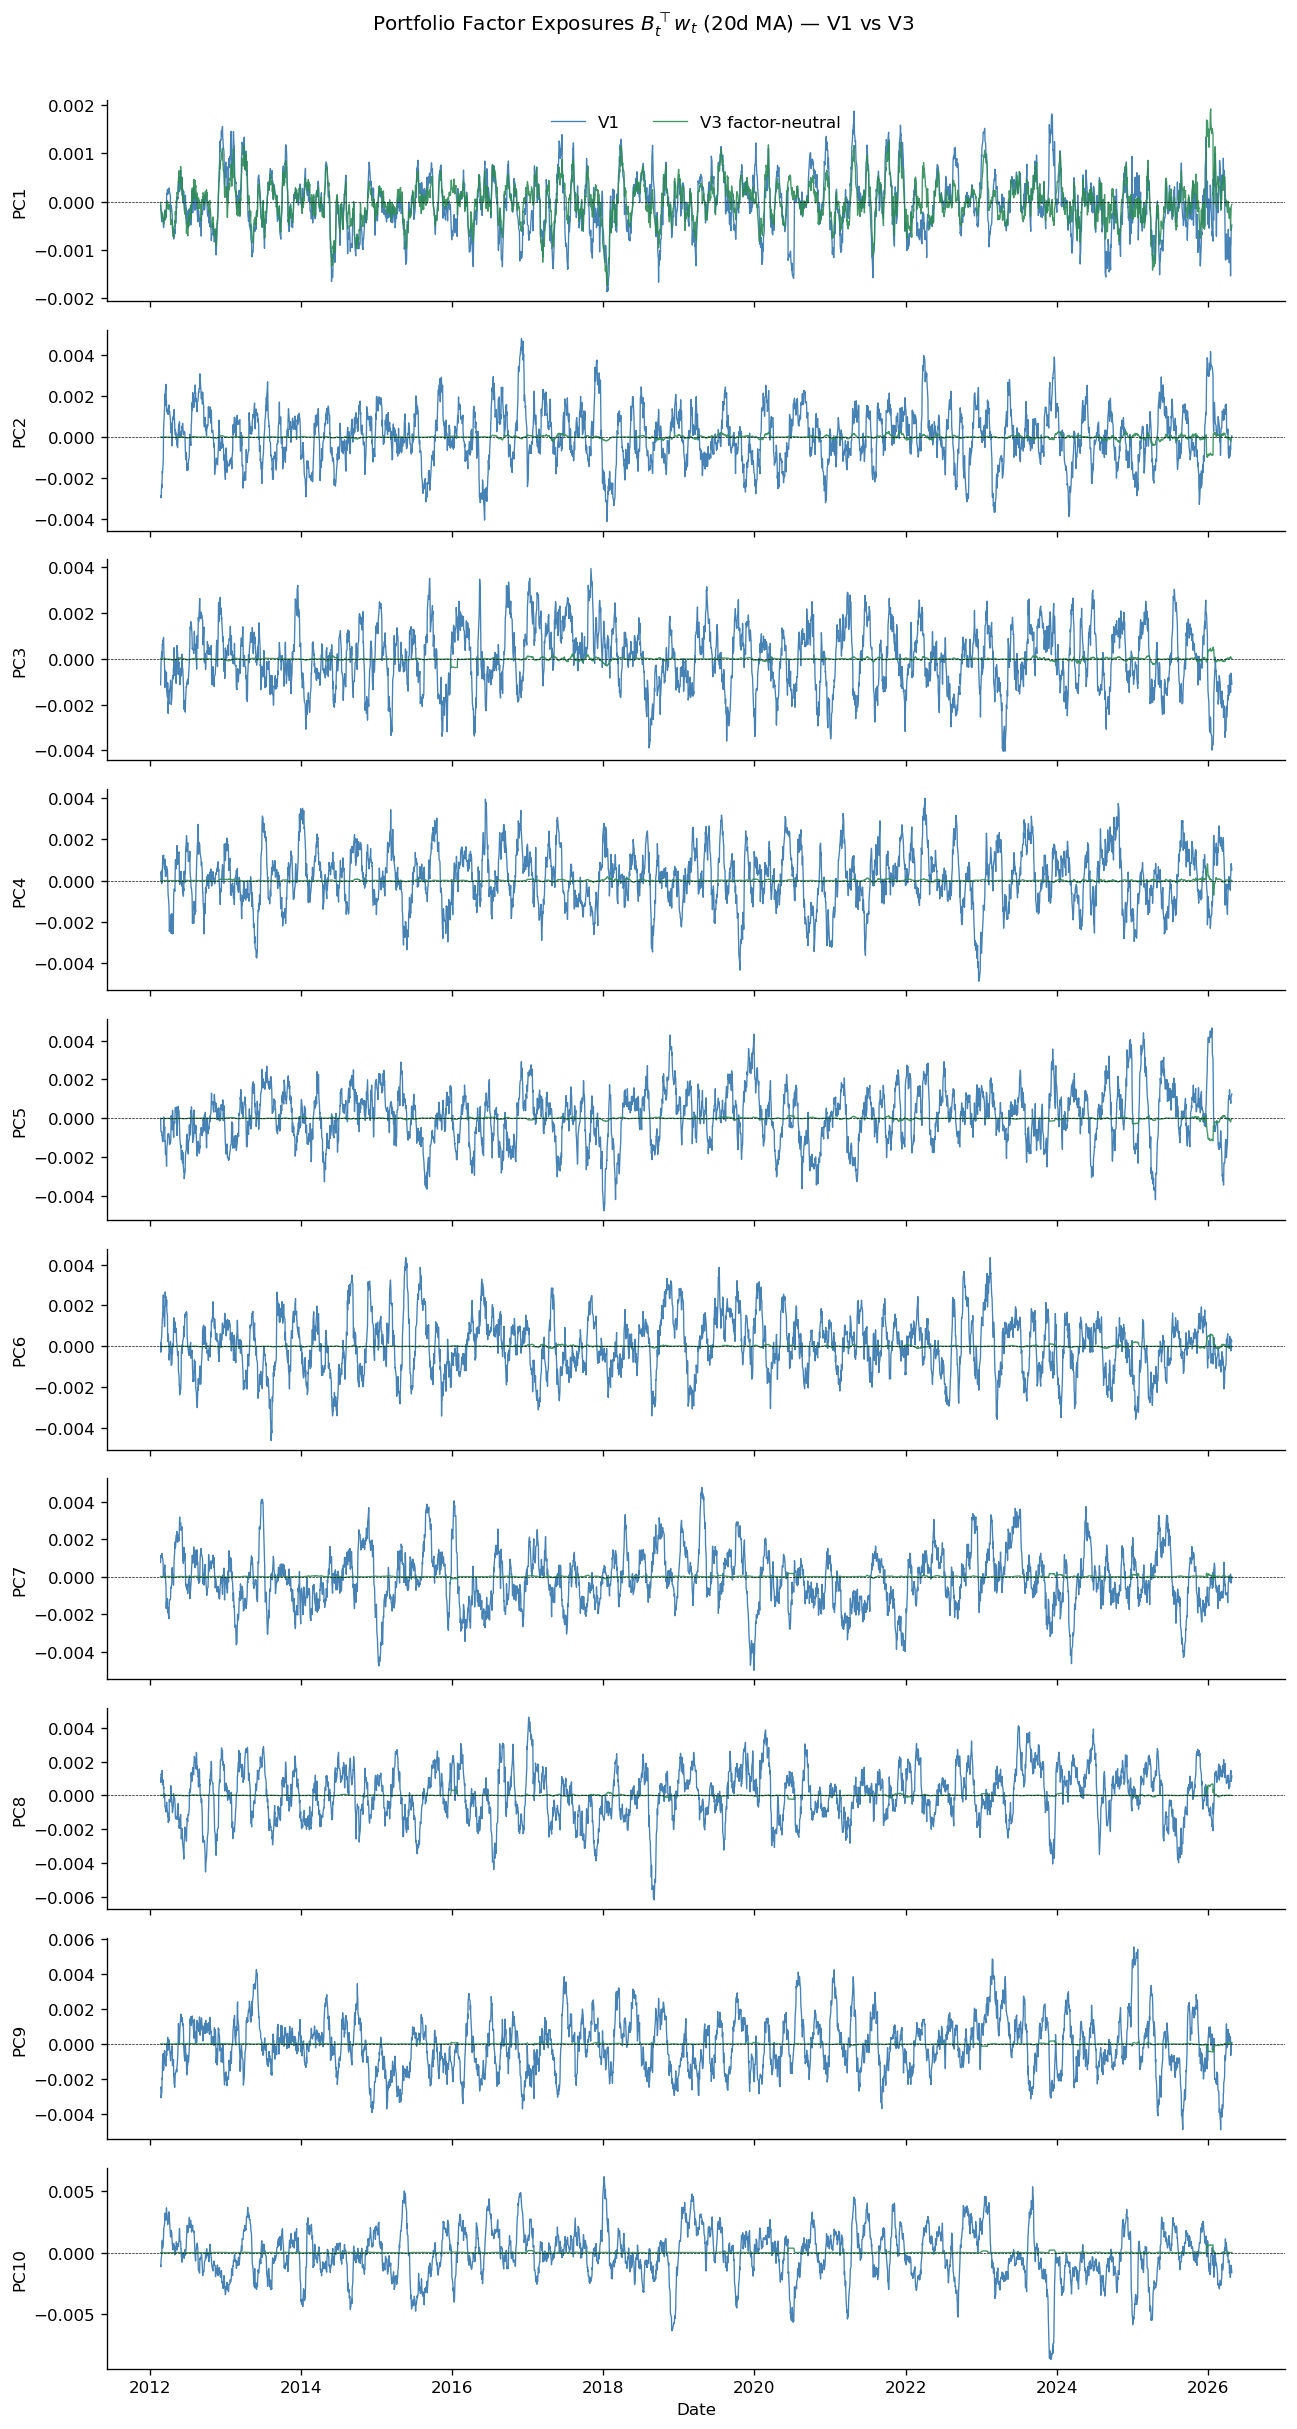

In [23]:
fig, axes = plt.subplots(k, 1, figsize=(11, 2 * k), sharex=True)
for j, ax in enumerate(axes):
    col = f"PC{j+1}"
    ax.plot(exp_v1.index, exp_v1[col].rolling(20).mean(),
            color="steelblue", linewidth=0.8, label="V1")
    ax.plot(exp_v3.index, exp_v3[col].rolling(20).mean(),
            color="seagreen",  linewidth=0.8, label="V3 factor-neutral", alpha=0.9)
    ax.axhline(0, color="black", linewidth=0.4, linestyle="--")
    ax.set_ylabel(col)
    if j == 0:
        ax.legend(frameon=False, ncol=2)
axes[-1].set_xlabel("Date")
fig.suptitle("Portfolio Factor Exposures $B_t^\\top w_t$ (20d MA) — V1 vs V3", y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Backtest Engine

At each date $t$, weights are formed using information through $t-1$. The portfolio is held from $t$ to $t+1$ and earns:

$$r_{p,t+1}^{\text{gross}} = \sum_i w_{i,t} \cdot r_{i,t+1}$$

Transaction costs are applied to daily weight changes (turnover):

$$r_{p,t+1}^{\text{net}} = r_{p,t+1}^{\text{gross}} - c \cdot \sum_i |w_{i,t} - w_{i,t-1}|$$

In [24]:
# Shared backtest and metric helpers now live in the package.
# backtest and perf_metrics were imported in Cell 1.

---
## 5. Results

In [25]:
# Timing convention: weights[t] pair with log_returns.shift(-1)[t] — no weight shift needed
bt_v1_0  = backtest(weights_v1, log_returns, cost_bps=0)
bt_v1_5  = backtest(weights_v1, log_returns, cost_bps=COST_BPS_MAIN)
bt_v2_0  = backtest(weights_v2, log_returns, cost_bps=0)
bt_v2_5  = backtest(weights_v2, log_returns, cost_bps=COST_BPS_MAIN)
bt_v3_0  = backtest(weights_v3, log_returns, cost_bps=0)
bt_v3_5  = backtest(weights_v3, log_returns, cost_bps=COST_BPS_MAIN)

print(f"Backtest date range : {bt_v1_0.index.min().date()}  →  {bt_v1_0.index.max().date()}")
print(f"Trading days        : {len(bt_v1_0)}")
print(f"\nMean daily turnover:")
for name, bt in [("V1", bt_v1_0), ("V2", bt_v2_0), ("V3", bt_v3_0)]:
    print(f"  {name}: {bt['turnover'].mean():.3f}")

Backtest date range : 2012-01-25  →  2026-04-27
Trading days        : 3584

Mean daily turnover:
  V1: 1.709
  V2: 1.749
  V3: 1.624


In [26]:
rows = {
    "V1  gross (0 bps)"   : perf_metrics(bt_v1_0["gross"]),
    "V1  net  (5 bps)"    : perf_metrics(bt_v1_5["net"]),
    "V2  gross (0 bps)"   : perf_metrics(bt_v2_0["gross"]),
    "V2  net  (5 bps)"    : perf_metrics(bt_v2_5["net"]),
    "V3  gross (0 bps)"   : perf_metrics(bt_v3_0["gross"]),
    "V3  net  (5 bps)"    : perf_metrics(bt_v3_5["net"]),
}

perf_df = pd.DataFrame(rows).T
fmt = {
    "Ann. Return"  : "{:.2%}",
    "Ann. Vol"     : "{:.2%}",
    "Sharpe"       : "{:.2f}",
    "Max Drawdown" : "{:.2%}",
    "Calmar"       : "{:.2f}",
    "Hit Rate"     : "{:.1%}",
    "N Days"       : "{:.0f}",
}
perf_df.style.format(fmt)

,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,Calmar,Hit Rate,N Days
V1 gross (0 bps),-1.85%,3.27%,-0.57,-31.16%,-0.06,48.1%,3584
V1 net (5 bps),-20.87%,3.27%,-6.38,-96.42%,-0.22,31.8%,3584
V2 gross (0 bps),-2.04%,3.63%,-0.56,-34.80%,-0.06,48.3%,3584
V2 net (5 bps),-21.42%,3.63%,-5.91,-96.76%,-0.22,32.5%,3584
V3 gross (0 bps),-1.58%,2.76%,-0.57,-27.04%,-0.06,48.5%,3584
V3 net (5 bps),-19.79%,2.76%,-7.18,-95.66%,-0.21,29.4%,3584


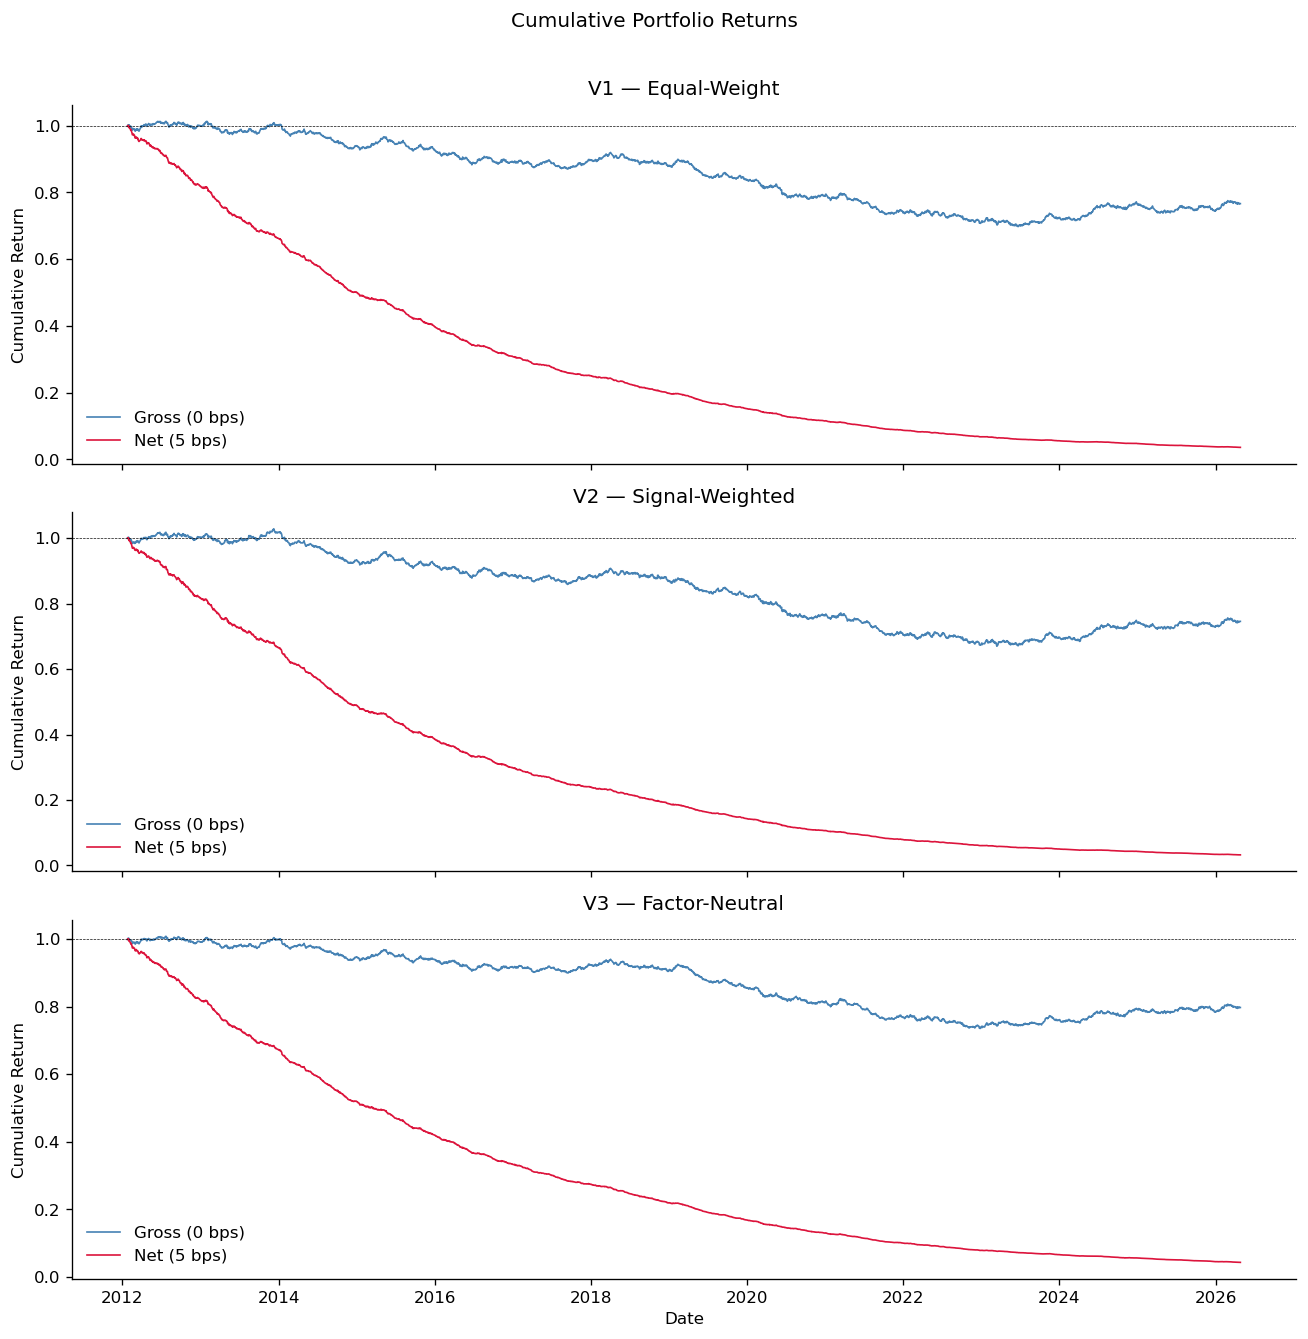

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(11, 11), sharex=True)

for ax, name, bt0, bt5 in zip(
    axes,
    ["V1 — Equal-Weight", "V2 — Signal-Weighted", "V3 — Factor-Neutral"],
    [bt_v1_0, bt_v2_0, bt_v3_0],
    [bt_v1_5, bt_v2_5, bt_v3_5],
):
    cum_gross = (1 + bt0["gross"]).cumprod()
    cum_net   = (1 + bt5["net"]).cumprod()
    ax.plot(cum_gross.index, cum_gross.values, color="steelblue", linewidth=1,   label="Gross (0 bps)")
    ax.plot(cum_net.index,   cum_net.values,   color="crimson",   linewidth=1,   label=f"Net ({COST_BPS_MAIN} bps)")
    ax.axhline(1, color="black", linewidth=0.4, linestyle="--")
    ax.set_ylabel("Cumulative Return")
    ax.set_title(name)
    ax.legend(frameon=False)

axes[-1].set_xlabel("Date")
plt.suptitle("Cumulative Portfolio Returns", y=1.01)
plt.tight_layout()
plt.show()

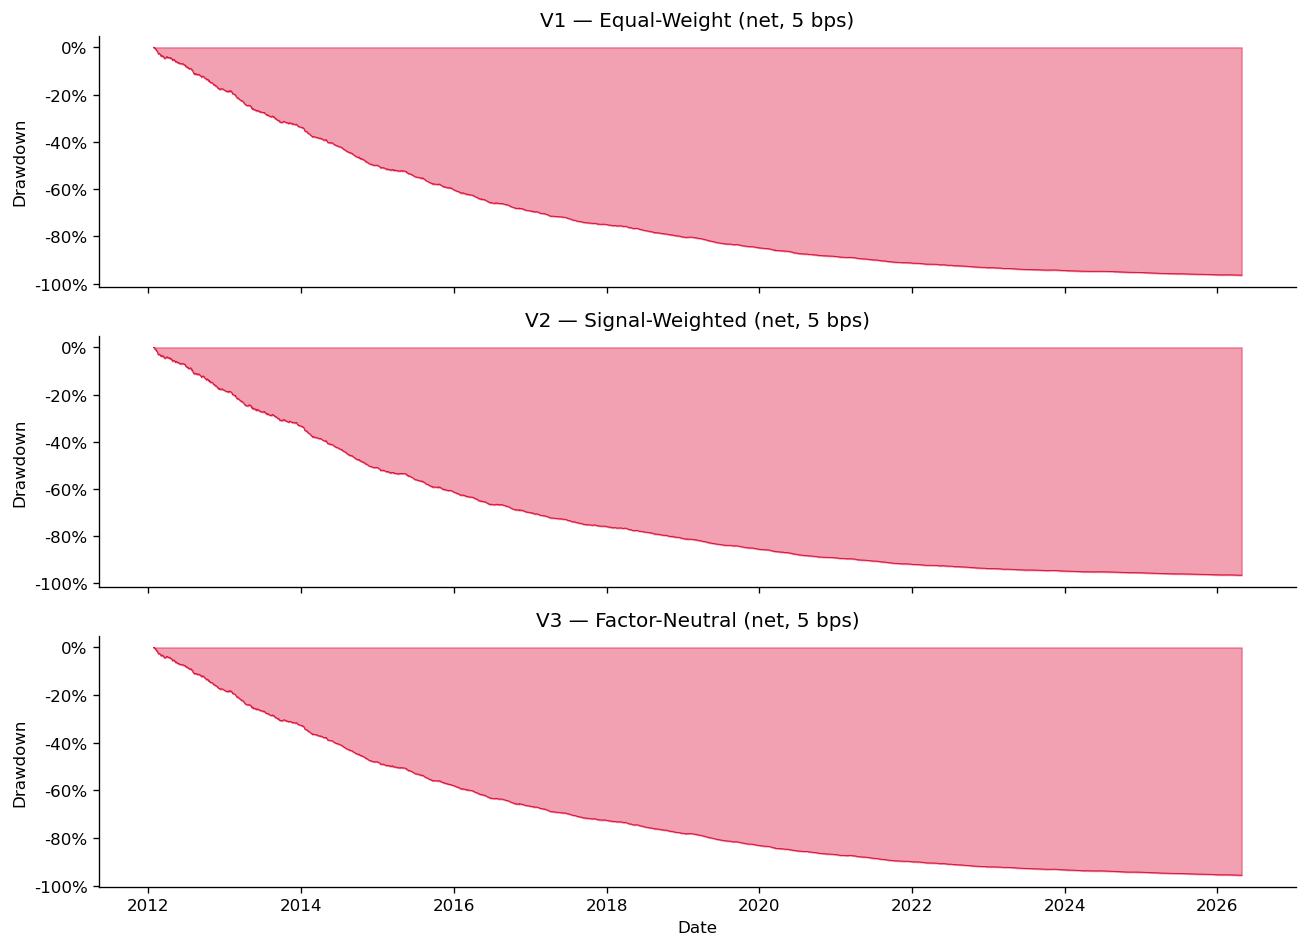

In [28]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

for ax, name, bt5 in zip(
    axes,
    [f"V1 — Equal-Weight (net, {COST_BPS_MAIN} bps)",
     f"V2 — Signal-Weighted (net, {COST_BPS_MAIN} bps)",
     f"V3 — Factor-Neutral (net, {COST_BPS_MAIN} bps)"],
    [bt_v1_5, bt_v2_5, bt_v3_5],
):
    cum = (1 + bt5["net"]).cumprod()
    dd  = cum / cum.cummax() - 1
    ax.fill_between(dd.index, dd.values, 0, color="crimson", alpha=0.4)
    ax.plot(dd.index, dd.values, color="crimson", linewidth=0.6)
    ax.set_ylabel("Drawdown")
    ax.set_title(name)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

---
## 6. Transaction Cost Sensitivity

How much does performance degrade as transaction costs increase? The signal survives costs if the Sharpe ratio remains meaningfully positive at realistic cost levels (5–10 bps).

In [29]:
cost_results = {}
for c_bps in COSTS:
    for name, w in [("V1", weights_v1), ("V2", weights_v2), ("V3", weights_v3)]:
        bt  = backtest(w, log_returns, cost_bps=c_bps)
        pm  = perf_metrics(bt["net"])
        cost_results[(name, f"{c_bps} bps")] = pm

cost_df = pd.DataFrame(cost_results).T[["Ann. Return", "Ann. Vol", "Sharpe", "Max Drawdown"]]
cost_df.index.names = ["Portfolio", "Cost"]

fmt2 = {"Ann. Return": "{:.2%}", "Ann. Vol": "{:.2%}",
        "Sharpe": "{:.2f}", "Max Drawdown": "{:.2%}"}
cost_df.style.format(fmt2)

,,Ann. Return,Ann. Vol,Sharpe,Max Drawdown
Portfolio,Cost,,,,
V1,0 bps,-1.85%,3.27%,-0.57,-31.16%
V2,0 bps,-2.04%,3.63%,-0.56,-34.80%
V3,0 bps,-1.58%,2.76%,-0.57,-27.04%
V1,1 bps,-5.99%,3.27%,-1.83,-59.24%
V2,1 bps,-6.27%,3.63%,-1.73,-60.65%
V3,1 bps,-5.52%,2.76%,-2.00,-55.75%
V1,5 bps,-20.87%,3.27%,-6.38,-96.42%
V2,5 bps,-21.42%,3.63%,-5.91,-96.76%
V3,5 bps,-19.79%,2.76%,-7.18,-95.66%


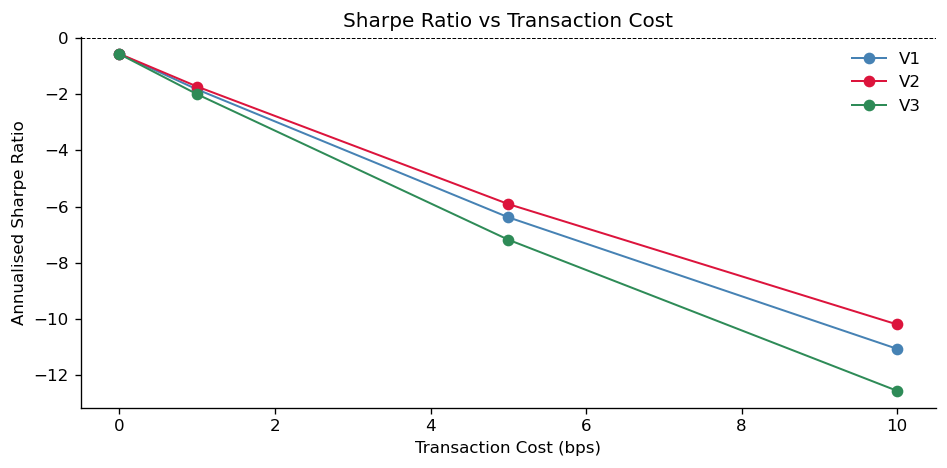

In [30]:
# Sharpe vs cost — visual
fig, ax = plt.subplots(figsize=(8, 4))

for name, color in [("V1", "steelblue"), ("V2", "crimson"), ("V3", "seagreen")]:
    sharpes = [cost_results[(name, f"{c} bps")]["Sharpe"] for c in COSTS]
    ax.plot(COSTS, sharpes, marker="o", color=color, linewidth=1.2, label=name)

ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_xlabel("Transaction Cost (bps)")
ax.set_ylabel("Annualised Sharpe Ratio")
ax.set_title("Sharpe Ratio vs Transaction Cost")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

---
## 7. Turnover Analysis

High turnover is the main risk for a daily mean-reversion strategy. If turnover is 1.0 (100% of the book traded each day), even 5 bps per trade costs 5 bps × 1.0 = 5 bps/day, which is ~12.6% annualised — difficult to overcome.

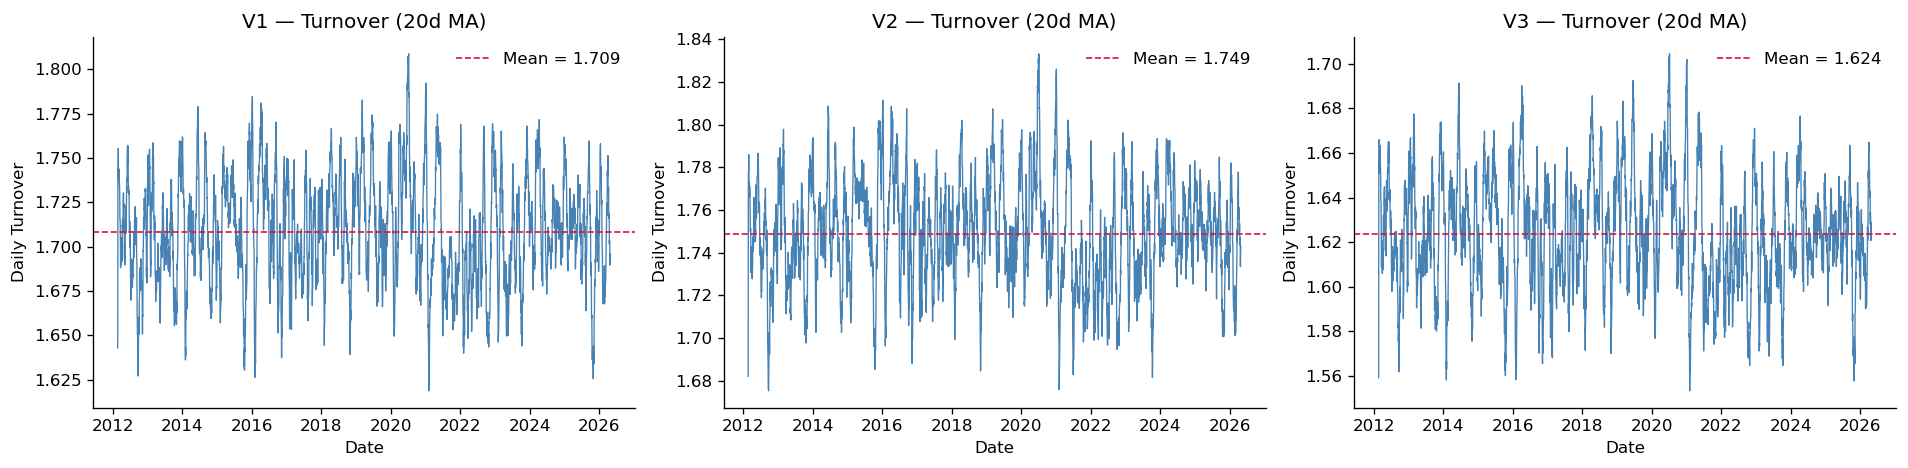

V1  mean daily turnover: 1.709 → implied annual cost @ 5 bps: 21.53%
V2  mean daily turnover: 1.749 → implied annual cost @ 5 bps: 22.03%
V3  mean daily turnover: 1.624 → implied annual cost @ 5 bps: 20.46%


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, name, bt in [
    (axes[0], "V1", bt_v1_0),
    (axes[1], "V2", bt_v2_0),
    (axes[2], "V3", bt_v3_0),
]:
    ax.plot(bt.index, bt["turnover"].rolling(20).mean(), color="steelblue", linewidth=0.8)
    ax.axhline(bt["turnover"].mean(), color="crimson", linewidth=1.0, linestyle="--",
               label=f"Mean = {bt['turnover'].mean():.3f}")
    ax.set_ylabel("Daily Turnover")
    ax.set_xlabel("Date")
    ax.set_title(f"{name} — Turnover (20d MA)")
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()

for name, bt in [("V1", bt_v1_0), ("V2", bt_v2_0), ("V3", bt_v3_0)]:
    to    = bt["turnover"].mean()
    cost5 = to * 5 * 1e-4 * 252
    print(f"{name}  mean daily turnover: {to:.3f} → implied annual cost @ 5 bps: {cost5:.2%}")

---
## 8. Save Results

In [32]:
tag = PCA_OUTPUT_SUFFIX

bt_v1_0[["gross", "net", "turnover"]].to_parquet(f"{PROCESSED}/backtest_v1_0bps{tag}.parquet")
bt_v1_5[["gross", "net", "turnover"]].to_parquet(f"{PROCESSED}/backtest_v1_5bps{tag}.parquet")
bt_v2_0[["gross", "net", "turnover"]].to_parquet(f"{PROCESSED}/backtest_v2_0bps{tag}.parquet")
bt_v2_5[["gross", "net", "turnover"]].to_parquet(f"{PROCESSED}/backtest_v2_5bps{tag}.parquet")
bt_v3_0[["gross", "net", "turnover"]].to_parquet(f"{PROCESSED}/backtest_v3_0bps{tag}.parquet")
bt_v3_5[["gross", "net", "turnover"]].to_parquet(f"{PROCESSED}/backtest_v3_5bps{tag}.parquet")
weights_v1.to_parquet(f"{PROCESSED}/weights_v1{tag}.parquet")
weights_v2.to_parquet(f"{PROCESSED}/weights_v2{tag}.parquet")
weights_v3.to_parquet(f"{PROCESSED}/weights_v3_factor_neutral{tag}.parquet")
perf_df.to_csv(f"{PROCESSED}/performance_table{tag}.csv")

print("Saved:")
for f in [
    f"backtest_v1_0bps{tag}", f"backtest_v1_5bps{tag}",
    f"backtest_v2_0bps{tag}", f"backtest_v2_5bps{tag}",
    f"backtest_v3_0bps{tag}", f"backtest_v3_5bps{tag}",
    f"weights_v1{tag}", f"weights_v2{tag}", f"weights_v3_factor_neutral{tag}",
    f"performance_table{tag}",
]:
    print(f"  {PROCESSED}/{f}")

Saved:
  ../data/processed/backtest_v1_0bps_L126_K10_M20
  ../data/processed/backtest_v1_5bps_L126_K10_M20
  ../data/processed/backtest_v2_0bps_L126_K10_M20
  ../data/processed/backtest_v2_5bps_L126_K10_M20
  ../data/processed/backtest_v3_0bps_L126_K10_M20
  ../data/processed/backtest_v3_5bps_L126_K10_M20
  ../data/processed/weights_v1_L126_K10_M20
  ../data/processed/weights_v2_L126_K10_M20
  ../data/processed/weights_v3_factor_neutral_L126_K10_M20
  ../data/processed/performance_table_L126_K10_M20
